In [210]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [211]:
import os
import rootutils

rootutils.setup_root(os.getcwd(), indicator=".project-root", pythonpath=True)

from torchvision import transforms
import torch
from src.data.components.graphs_datamodules import (
    IMCBaseDictTransform,
    PickleDataset,
    PatchAugmentations,
)
from src.data.imc_datamodule import add_channel
import src.data.components.graphs_datamodules as gd
from torchvision.datasets import MNIST
from torch.utils.data import ConcatDataset, Dataset, random_split

from pathlib import Path

from src.models.components.plot import restore_tensor, plot_feature_map

from src.models.pigvae_auto_module import PLGraphAE
from src.models.components.modules import GraphAE
from src.models.components.schedulers import TemperatureScheduler, EntropyWeightScheduler, KLDAlphaScheduler
from src.models.components.model import Critic
from src.data.components.graphs_datamodules import DenseGraphBatch

from torch.nn import MSELoss, L1Loss, CosineSimilarity


In [212]:
from src.models.components.plot import restore_tensor
import matplotlib.pyplot as plt

base_transforms = IMCBaseDictTransform(center_crop_size=7, normalize=False)

aug_transforms_train = gd.PatchAugmentations(
    prob=1.0,
    size=15,
    patch_size=1,
    center_crop_size=7
)

aug_transforms_val = gd.PatchAugmentations(
    prob=1.0,
    size=15,
    patch_size=1,
    is_validation=True,
    center_crop_size=7
)

dual_transforms_train = gd.DualOutputTransform(base_transforms, aug_transforms_train)

dual_transforms_val = gd.DualOutputTransform(base_transforms, aug_transforms_val)

train_path = Path("/raid/tnocon/data") / "IMC" / "nsclc2_panel1_train.h5"
test_path = Path("/raid/tnocon/data") / "IMC" / "nsclc2_panel1_test.h5"
# statistics_path = Path("/raid/tnocon/data") / "IMC" / "imc_statistics.pt"
# stats = torch.load(statistics_path, map_location="cpu")
# mean = stats["mean"]
# std = stats["std"]
# dual_transforms_train.set_mean(mean)
# dual_transforms_train.set_std(std)
# dual_transforms_val.set_mean(mean)
# dual_transforms_val.set_std(std)

trainset = PickleDataset(train_path, transform=dual_transforms_train)
testset = PickleDataset(test_path, transform=dual_transforms_val)

train_ratio, val_ratio, test_ratio, leftover_ratio = [10800, 360, 0, 3996 + 7308]  #[18108, 5040, 0, 0]

size_trainset = len(trainset)
size_testset = len(testset)
data_train, _ = random_split(
    dataset=trainset,
    lengths=[train_ratio, size_trainset - train_ratio],
    generator=torch.Generator().manual_seed(42),
)

data_val, data_test, _ = random_split(
    dataset=testset,
    lengths=[val_ratio, test_ratio, size_testset - val_ratio - test_ratio],
    generator=torch.Generator().manual_seed(42),
)

train_dataset = gd.GridGraphDataset(grid_size=15, dataset=data_train, channels=list(range(64)))
val_dataset = gd.GridGraphDataset(grid_size=15, dataset=data_val, channels=list(range(64)))

train_loader = gd.DenseGraphDataLoader(
    dataset=train_dataset,
    batch_size=8,
    num_workers=7,
    pin_memory=False,
    persistent_workers=7 > 0,
)

val_loader = gd.DenseGraphDataLoader(
    dataset=val_dataset,
    batch_size=8,
    num_workers=7,
    pin_memory=False,
    persistent_workers=7 > 0,
)

In [213]:
import numpy as np

def to_numpy(x):
    """Convert tensor-like input to a 1D NumPy array."""
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy().ravel()
    return np.asarray(x).ravel()

def plot_tensor_histogram(tensor, bins=500, title="Histogram of tensor values"):
    values = to_numpy(tensor)

    plt.figure()
    plt.hist(values, bins=bins)
    plt.title(title)
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

In [214]:
import yaml
from omegaconf import OmegaConf

# Path to your YAML config file
config_path = "../configs/model/model.yaml"

# Load the YAML file
with open(config_path, "r") as f:
    model_config_raw = yaml.safe_load(f)

print("Converting configurations to DictConfig...")

# Register multiply resolver if not already registered
if not OmegaConf.has_resolver("multiply"):
    OmegaConf.register_new_resolver("multiply", lambda x, y: x * y)

# Register divide resolver if not already registered
if not OmegaConf.has_resolver("divide"):
    OmegaConf.register_new_resolver("divide", lambda x, y: x // y)

# Wrap the config under 'model' and 'data' keys so interpolations work
# Also provide the missing data.hparams.num_aug_per_sample value
full_config = OmegaConf.create({
    "model": model_config_raw,
    "data": {
        "hparams": {
            "num_aug_per_sample": 8,
            "batch_size": 8
        }
    },
    "trainer": {
        "max_epochs": 500,  # Set these to match your training config
        "min_epochs": 1
    }
})

# Now resolve all interpolations
OmegaConf.resolve(full_config)

print("Creating GraphAE from resolved config...")
graph_ae = GraphAE(hparams=full_config.model.graph_ae.hparams)
print("GraphAE created successfully!")

print("Creating schedulers...")
temperature_scheduler = TemperatureScheduler(hparams=full_config.model.temperature_scheduler.hparams)
entropy_weight_scheduler = EntropyWeightScheduler(hparams=full_config.model.entropy_weight_scheduler.hparams)
# kld_alpha_scheduler = KLDAlphaScheduler(hparams=full_config.model.kld_alpha_scheduler.hparams)

print("Creating critic...")
critic = Critic(hparams=full_config.model.critic.hparams)

print("Creating optimizer (dummy for loading)...")
# Create a dummy optimizer for loading (it will be overridden by the checkpoint)
optimizer = torch.optim.Adam(graph_ae.parameters(), lr=0.0001)

print("Creating scheduler (dummy for loading)...")
# Create a dummy scheduler for loading
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1)

print("All components created successfully!")


Converting configurations to DictConfig...
Creating GraphAE from resolved config...
GraphAE created successfully!
Creating schedulers...
Creating critic...
Creating optimizer (dummy for loading)...
Creating scheduler (dummy for loading)...
All components created successfully!


In [215]:
# Create the PLGraphAE model
print("Creating PLGraphAE model...")
model = PLGraphAE(
    graph_ae=graph_ae,
    critic=critic,
    temperature_scheduler=temperature_scheduler,
    entropy_weight_scheduler=entropy_weight_scheduler,
    # kld_alpha_scheduler=kld_alpha_scheduler,
    optimizer=optimizer,
    scheduler=scheduler,
    compile=False
)

print("PLGraphAE model created successfully!")


Creating PLGraphAE model...


/home/tnocon/master_thesis/IMMUVIS-PIGVAE/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'critic' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['critic'])`.
/home/tnocon/master_thesis/IMMUVIS-PIGVAE/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'temperature_scheduler' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['temperature_scheduler'])`.
/home/tnocon/master_thesis/IMMUVIS-PIGVAE/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'entropy_weight_scheduler' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['entropy_weight_scheduler'])`.
/home/tnocon/master_thesis/IMMUVIS

PLGraphAE model created successfully!


In [216]:
# Load the checkpoint
checkpoint_path = "/raid/tnocon/logs/train/runs/2025-11-24_00-42-09/checkpoints/last.ckpt"



print(f"Loading checkpoint from: {checkpoint_path}")
print("This may take a moment...")

# Load the checkpoint with weights_only=False since this is a Lightning checkpoint
# that contains more than just weights (it's safe since this is our own trained model)
checkpoint = torch.load(checkpoint_path, map_location='cuda', weights_only=False)
print("Checkpoint loaded successfully!")

# Load the state dict into the model
model.load_state_dict(checkpoint['state_dict'])
print("Model weights loaded successfully!")

# Set model to evaluation mode
model.eval()
print("Model is ready for inference!")


Loading checkpoint from: /raid/tnocon/logs/train/runs/2025-11-24_00-42-09/checkpoints/last.ckpt
This may take a moment...
Checkpoint loaded successfully!
Model weights loaded successfully!
Model is ready for inference!


In [217]:
# Optional: Move model to GPU if available
device = 'cuda'
model = model.to(device)
print(f"Model moved to device: {device}")

# Display model summary
print("\nModel loaded successfully!")
print(f"- Checkpoint epoch: {checkpoint.get('epoch', 'Unknown')}")
print(f"- Global step: {checkpoint.get('global_step', 'Unknown')}")
print(f"- Model device: {next(model.parameters()).device}")
print(f"- Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"- Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


Model moved to device: cuda

Model loaded successfully!
- Checkpoint epoch: 43
- Global step: 29700
- Model device: cuda:0
- Model parameters: 14,115,976
- Trainable parameters: 14,115,912


In [218]:
for el in train_loader:
    break

In [219]:
el.node_features.shape

torch.Size([64, 49, 64])

In [220]:
el = el.to('cuda')
model.eval()
with torch.no_grad():
    graph_emb, graph_pred, soft_probs, perm, mu, logvar = model(el, training=True, tau=model.temperature_scheduler(86))

In [221]:
el = el.to('cpu')
graph_pred = graph_pred.to('cpu')
graph_emb = graph_emb.to('cpu')

In [226]:
import src.models.components.metrics.recontructions as R

batch_size = 8
idx_to_show = R.batch_augmented_indices(
    batch_size, num_permutations=8, n_examples=8
)

In [227]:
idx_to_show

array([ 0,  8, 16, 24, 32, 40, 48, 56,  1,  9, 17, 25, 33, 41, 49, 57,  2,
       10, 18, 26, 34, 42, 50, 58,  3, 11, 19, 27, 35, 43, 51, 59,  4, 12,
       20, 28, 36, 44, 52, 60,  5, 13, 21, 29, 37, 45, 53, 61,  6, 14, 22,
       30, 38, 46, 54, 62,  7, 15, 23, 31, 39, 47, 55, 63])

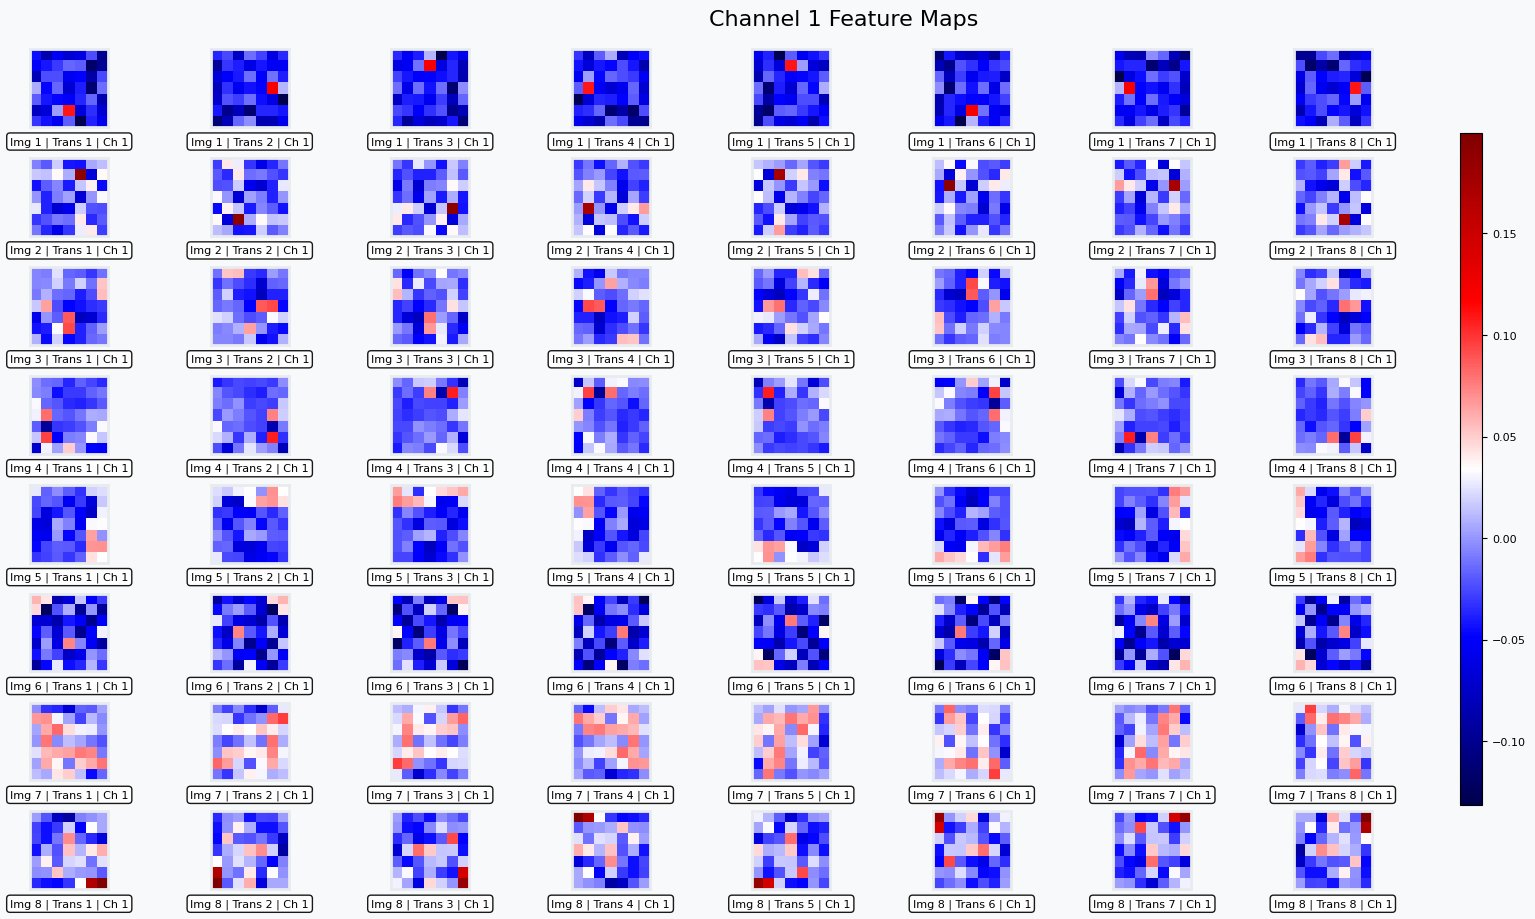

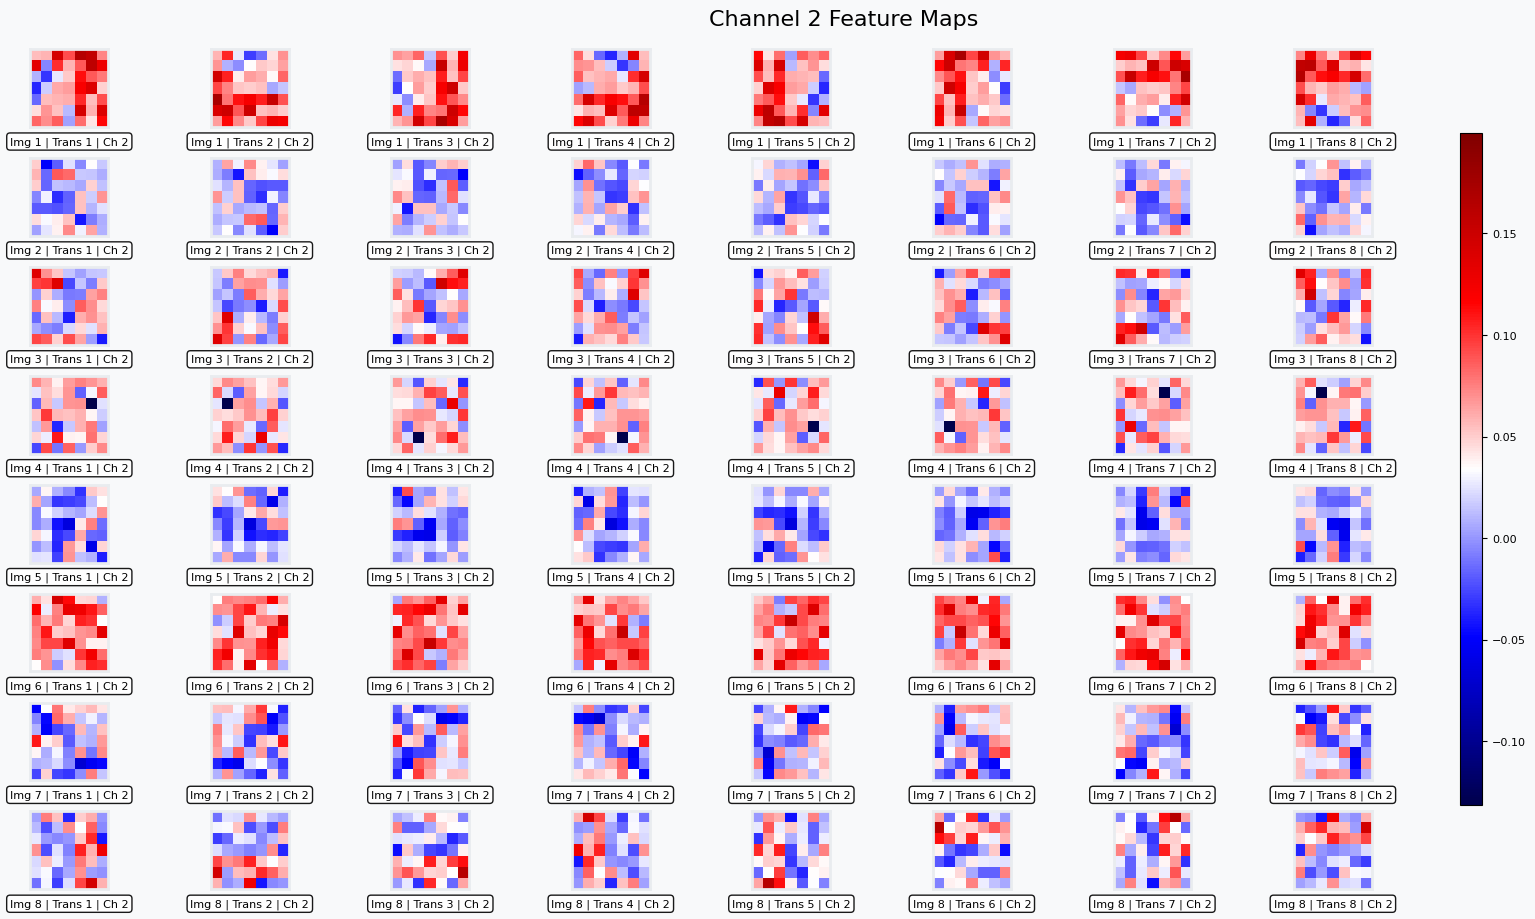

In [228]:
plot_feature_map(el.node_features[idx_to_show, :, :], 8)
plt.show()

[<Figure size 2000x1000 with 65 Axes>, <Figure size 2000x1000 with 65 Axes>]

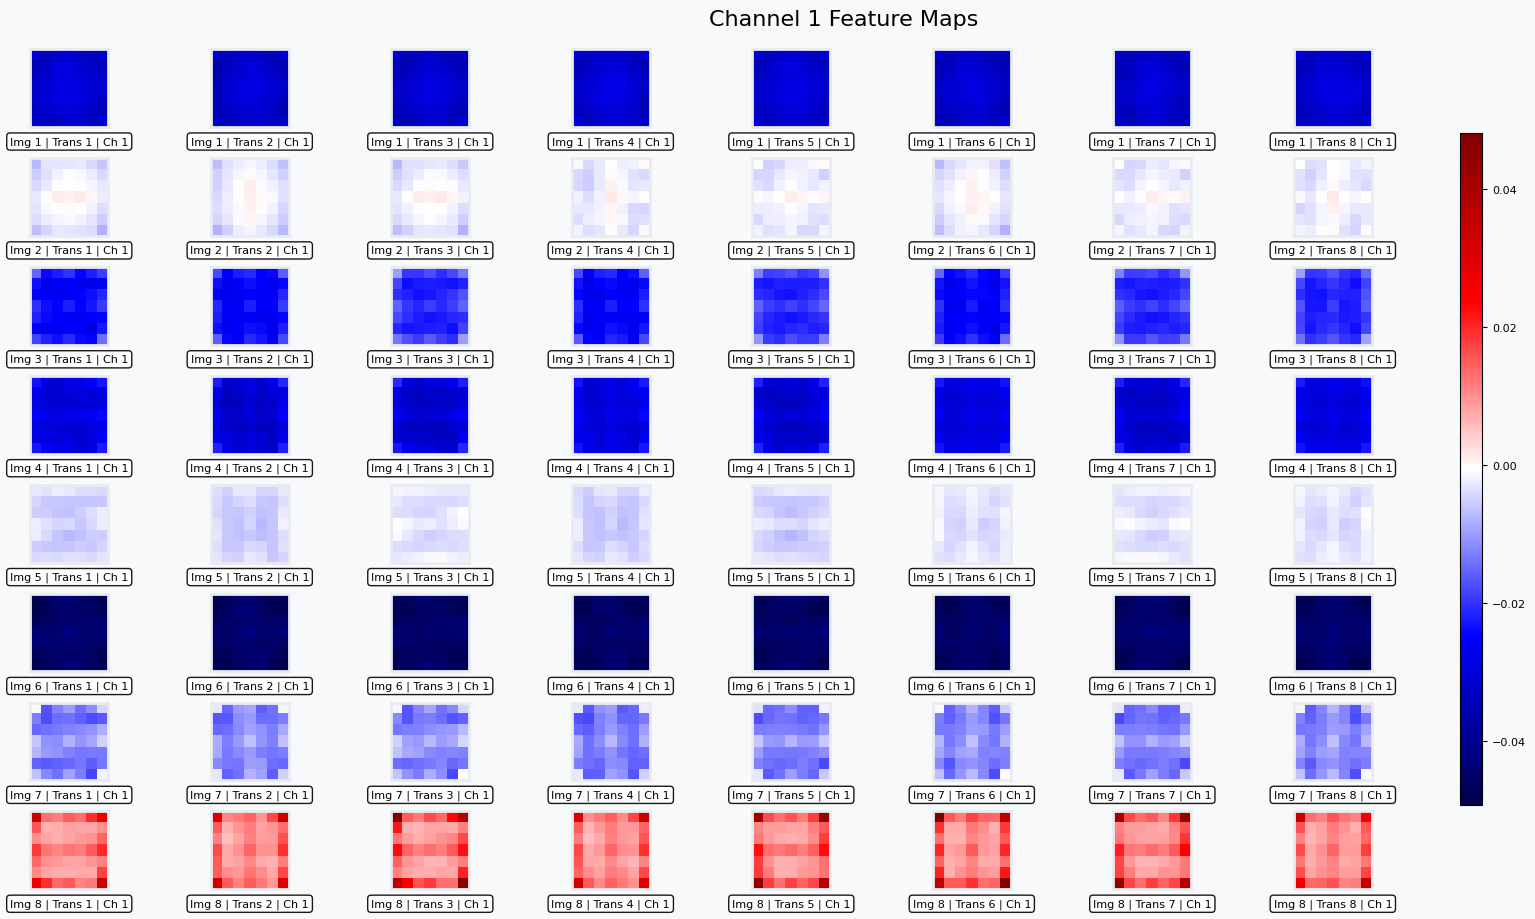

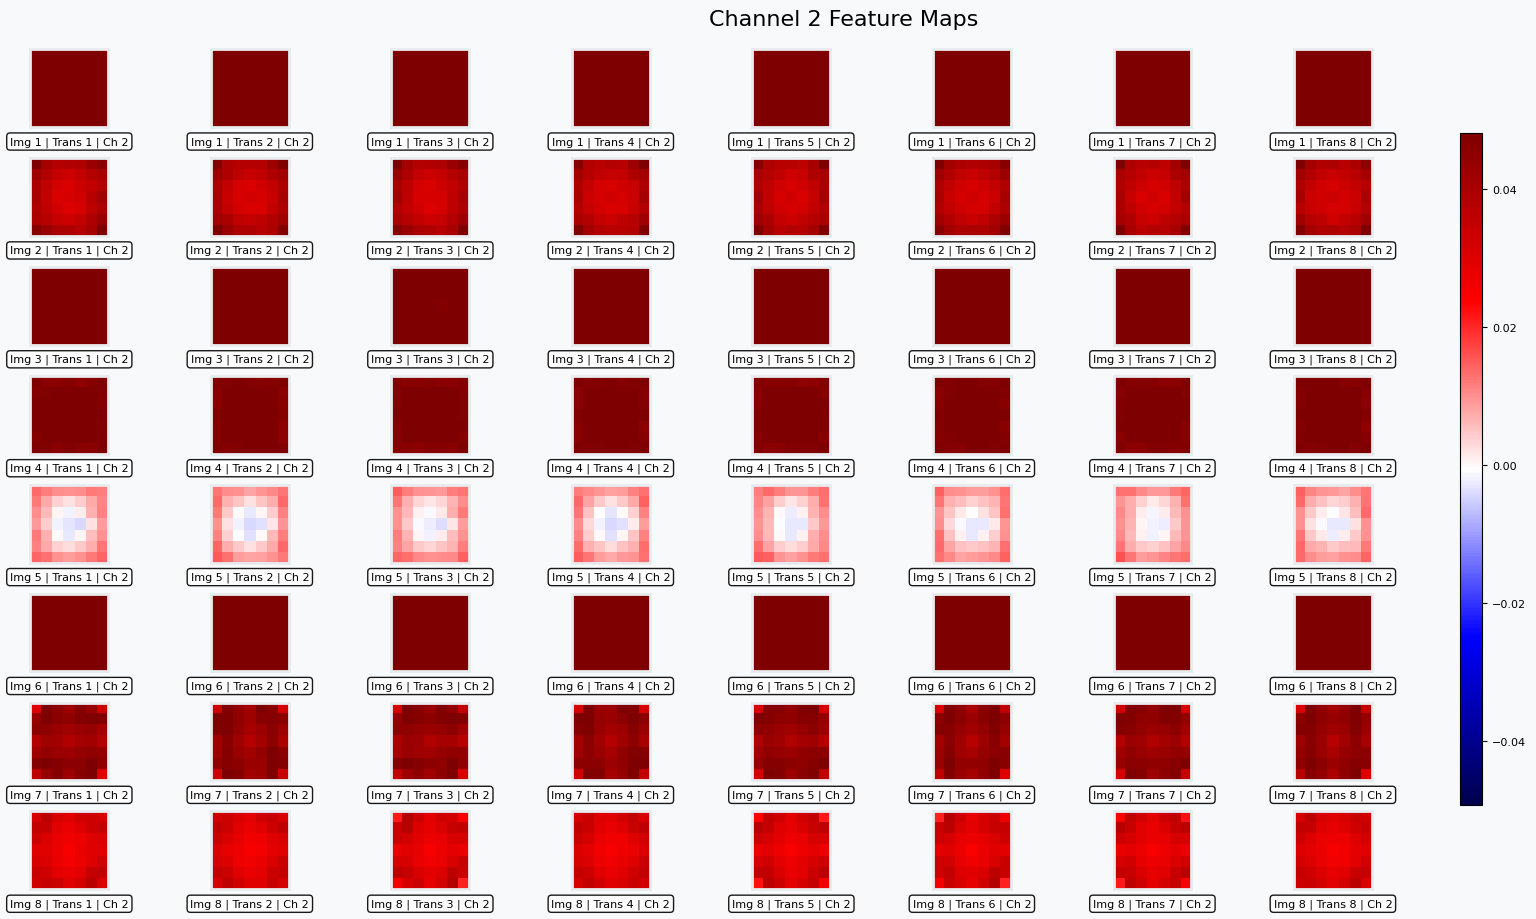

In [232]:
plot_feature_map(graph_pred.node_features[idx_to_show, :, :], 8)

In [185]:
from src.models.components.losses import (
    GraphReconstructionLoss,
    KLDLoss,
    PermutationLoss,
    MAELoss,
    CosineSimilarityLoss,
    SignalToNoiseRatioLoss,
    HuberLoss,
    GradientLoss,
    MSEGridLoss,
    LaplacianLoss,
    SSIMLoss
)

In [146]:
reconstruction_loss = GraphReconstructionLoss(
            loss_alpha=HuberLoss(1.0),
            loss_beta=CosineSimilarityLoss(),
            loss_gamma=LaplacianLoss(),
            alpha=1.0,
            beta=0.1,
            gamma=0.05,
        )

In [150]:
model.critic.evaluate(
    graph_emb=graph_emb,
    graph_true=el,
    graph_pred=graph_pred,
    mu=mu,
    logvar=logvar,
    beta=0.0,
    soft_probs=soft_probs,
    perm=perm,
)

{'alpha_recon': tensor(0.0009),
 'beta_recon': tensor(0.2620),
 'gamma_recon': tensor(0.2563),
 'loss': tensor(4.0399, device='cuda:0'),
 'permutation_loss': 0,
 'mae_loss': tensor(0.0327),
 'signal_to_noise_ratio_loss': tensor(3.8911),
 'mse_loss': tensor(0.0018),
 'kld_loss': tensor(4., device='cuda:0')}

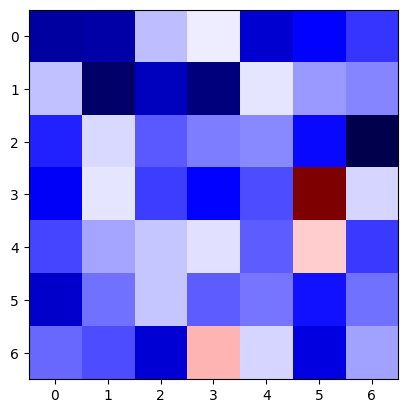

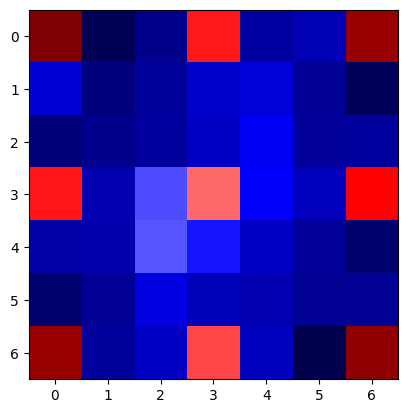

In [174]:
plt.imshow(el.node_features[0].permute(1, 0).reshape(64, 7, 7)[0], cmap="seismic")
plt.show()
plt.imshow(graph_pred.node_features[0].permute(1, 0).reshape(64, 7, 7)[0], cmap="seismic")
plt.show()

In [177]:
a = el.node_features[0].permute(1, 0).reshape(64, 7, 7)[0] - graph_pred.node_features[0].permute(1, 0).reshape(64, 7, 7)[0]

In [176]:
MSELoss()(el.node_features[0].permute(1, 0).reshape(64, 7, 7)[0], graph_pred.node_features[0].permute(1, 0).reshape(64, 7, 7)[0])

tensor(0.0015)

In [182]:
sum(sum(a ** 2)) / a.numel()

tensor(0.0015)

In [184]:
el.node_features[0].permute(1, 0).reshape(64, 7, 7)[0]

tensor([[-0.1004, -0.0978, -0.0245, -0.0136, -0.0844, -0.0688, -0.0568],
        [-0.0236, -0.1182, -0.0897, -0.1124, -0.0153, -0.0334, -0.0377],
        [-0.0613, -0.0185, -0.0482, -0.0394, -0.0364, -0.0668, -0.1284],
        [-0.0705, -0.0153, -0.0548, -0.0682, -0.0510,  0.1096, -0.0189],
        [-0.0527, -0.0299, -0.0230, -0.0162, -0.0474,  0.0022, -0.0550],
        [-0.0858, -0.0421, -0.0230, -0.0474, -0.0412, -0.0647, -0.0428],
        [-0.0438, -0.0512, -0.0820,  0.0073, -0.0189, -0.0784, -0.0309]])

In [203]:
ssim = SSIMLoss()
t = el.node_features[0].permute(1, 0).reshape(64, 7, 7)
p = graph_pred.node_features[0].permute(1, 0).reshape(64, 7, 7)

# t = t.unsqueeze(0)        # becomes (1, 64, 7, 7)
# p = p.unsqueeze(0) 
# ssim(p, t)


In [209]:
from src.models.components.losses import LPIPSLoss


proj = torch.nn.Conv2d(64, 3, kernel_size=1)
pred_rgb = proj(p).unsqueeze(0)       # (1, 3, 7, 7)
target_rgb = proj(t).unsqueeze(0)   # (1, 3, 7, 7)

# LPIPS networks (VGG/AlexNet) require H, W >= 32
pred_rgb = torch.nn.functional.interpolate(pred_rgb, size=(32, 32), mode='bilinear', align_corners=False)
target_rgb = torch.nn.functional.interpolate(target_rgb, size=(32, 32), mode='bilinear', align_corners=False)

pred_rgb = 2 * (pred_rgb - pred_rgb.min()) / (pred_rgb.max() - pred_rgb.min()) - 1
target_rgb = 2 * (target_rgb - target_rgb.min()) / (target_rgb.max() - target_rgb.min()) - 1


loss_fn = LPIPSLoss()

lpips_value = loss_fn(pred_rgb, target_rgb)  # shape: (1, 1, 1, 1)
print("LPIPS:", lpips_value.item())


Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/home/tnocon/master_thesis/IMMUVIS-PIGVAE/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/tnocon/master_thesis/IMMUVIS-PIGVAE/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /home/tnocon/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:04<00:00, 118MB/s] 


Loading model from: /home/tnocon/master_thesis/IMMUVIS-PIGVAE/.venv/lib/python3.12/site-packages/lpips/weights/v0.1/vgg.pth
LPIPS: 0.38647666573524475


In [208]:
pred_rgb.shape

torch.Size([3, 7, 7])